In [1]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers

In [2]:
def generate_regression_data():
    X, y = make_regression(n_samples=1000, n_features=5, n_informative=3, noise=15)
    
    y = y + 30 * np.sin(X[:, 0])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(X_train)
    x_test_scaled = scaler.transform(X_test)

    return x_train_scaled, x_test_scaled, y_train, y_test

In [3]:
def build_model(input_dim, hidden_layers: list, activation: list | str, type_of_cat):

    if isinstance(activation, str):
        activations = [activation] * len(hidden_layers)
    else:
        activations = activation
    
    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))
    
    for units, act in zip(hidden_layers, activations):
        model.add(layers.Dense(units, activation=act))
    if type_of_cat == "classification":
        model.add(layers.Dense(1, activation='sigmoid'))
    elif type_of_cat == "regression":
        model.add(layers.Dense(1))
    else:
        print("pick regression or classification")

    return model 

In [4]:
def train_model(model, X_train, y_train, epochs, type_of_cat, verbose = 0):

    if type_of_cat == "classification":
        model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy'])
            
    elif type_of_cat == "regression":
        model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='mse')
    else:
        print("pick regression or classification")
        
    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs)

    return history

In [5]:

def plot_history(history, cat_type: str = "classification", title: str = ""):
    if cat_type == "classification":
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Wykres Loss
        axes[0].plot(history.history['loss'], label='Trening (loss)', color='blue')
        axes[0].plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
        axes[0].set_title(f"{title} - Loss")
        axes[0].set_xlabel('Epoki')
        axes[0].set_ylabel('Loss')
        axes[0].set_yscale('log')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # Wykres Accuracy
        axes[1].plot(history.history['accuracy'], label='Trening (acc)', color='blue')
        axes[1].plot(history.history['val_accuracy'], label='Walidacja (val_acc)', color='red')
        axes[1].set_title(f"{title} - Accuracy")
        axes[1].set_xlabel('Epoki')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)

    elif cat_type == "regression":
        # Dla regresji generujemy pojedynczy, dopasowany wykres
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Trening (loss)', color='blue')
        plt.plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
        plt.title(f"{title} - Loss (MSE)")
        plt.xlabel('Epoki')
        plt.ylabel('Loss')
        plt.yscale('log')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)

    else:
        raise ValueError(f"Nieznany typ: '{cat_type}'. Wybierz 'classification' lub 'regression'.")

    plt.tight_layout()
    plt.show()

In [6]:
X_train_scaled, X_test_scaled, y_train, y_test = generate_regression_data()

In [7]:
model = build_model(5, [16], 'relu', type_of_cat="regression")

In [8]:
history = train_model(model, X_train_scaled, y_train, epochs=200, type_of_cat="regression")

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20232.3105 - val_loss: 21990.0332
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19697.6484 - val_loss: 21180.2812
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18740.4180 - val_loss: 19766.5430
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17191.7188 - val_loss: 17644.1562
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15004.4561 - val_loss: 14906.6064
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12359.5518 - val_loss: 11875.4092
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9575.2324 - val_loss: 8865.7559
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6948.0859 - val_loss: 6221.5405
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4793.9028 - val_loss: 4091.4492
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3110.0166 - val_loss: 2627.5383
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1991.8962 - val_l

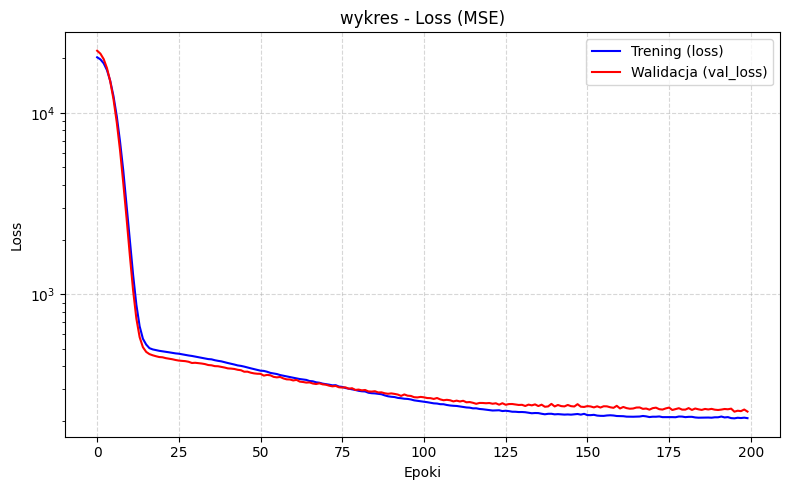

In [9]:
wykres = plot_history(history, "regression", "wykres")

In [10]:
# jak linie sie rozjezdaja to oznacza overfitting

# zadanie 2

In [11]:
dict1 = {"no_hidden": [], "small": [8], "medium": [32], "two_layers": [64, 64], "large": [128, 128, 128]}

def compare_models(configs, data, epochs):

    histories = {}

    X_train_scaled, y_train = data

    for name, layers_num in configs.items():

        model= Sequential()
        model.add(layers.Input(shape=(5, )))
        
        for layer in layers_num:
    
            model.add(layers.Dense(layer, activation='relu'))

        model.add(layers.Dense(1))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='mse',metrics=['mae'])
        history = model.fit(X_train_scaled, y_train, validation_split = 0.2, verbose=0, epochs= epochs)
        histories[name] = history
        
    return histories

In [12]:
data_xy = (X_train_scaled, y_train)

In [13]:
models = compare_models(dict1, data_xy, epochs=150)

In [14]:
models

{'no_hidden': <keras.src.callbacks.history.History at 0x123acd950>,
 'small': <keras.src.callbacks.history.History at 0x123ace490>,
 'medium': <keras.src.callbacks.history.History at 0x1234e16e0>,
 'two_layers': <keras.src.callbacks.history.History at 0x1234e1a70>,
 'large': <keras.src.callbacks.history.History at 0x1240316d0>}

In [15]:
models['no_hidden'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [16]:
def to_df(models):
    data = []
    for name, history in models.items():
        mini_data = {"name" :name,
                     "mae" : history.history['mae'][-1],
                     "loss": history.history['loss'][-1],
                     "val_loss": history.history['val_loss'][-1]
                    }
        data.append(mini_data)
    
    df = pd.DataFrame(data)
    return df


In [51]:
df = to_df(models)
df

,name,mae,loss,val_loss
0,no_hidden,112.182823,19063.218750,20932.091797
1,small,42.950336,3320.453613,3772.774658
2,medium,16.903751,463.985901,430.164551
3,two_layers,11.182698,199.414139,225.798828
4,large,9.875115,154.038956,277.349731


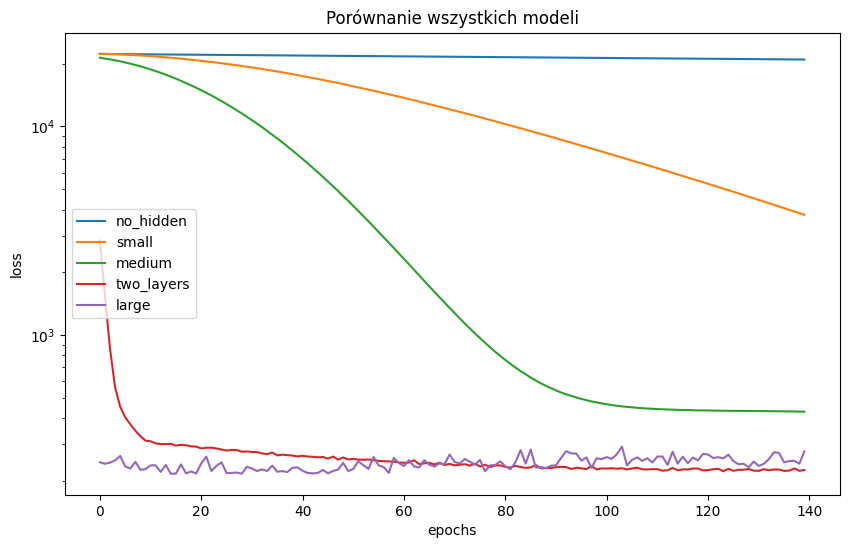

In [19]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(models)

In [20]:
# najlepiej wyszedl model bez warstw, a najgorzej model large. przeuczenia nie ma. model large jest niestabilny

# zadanie 3 

In [21]:
act_to_test = ['linear', 'sigmoid', 'tanh', 'relu', 'elu']

In [22]:
X_train_scaled_2, X_test_scaled_2, y_train_2, y_test_2 = generate_regression_data()

In [23]:
histories_2 = {}

for act in act_to_test:
    model = Sequential([
        layers.Input(shape=(5,)),
        layers.Dense(32, activation=act),
        layers.Dense(32, activation=act),
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    histories_2[act] = model.fit(
        X_train_scaled_2, 
        y_train_2, 
        validation_split=0.2, 
        verbose=0, 
        epochs=100
    )
histories_2

{'linear': <keras.src.callbacks.history.History at 0x12405bbd0>,
 'sigmoid': <keras.src.callbacks.history.History at 0x124d4ee00>,
 'tanh': <keras.src.callbacks.history.History at 0x123b77750>,
 'relu': <keras.src.callbacks.history.History at 0x1252d1a50>,
 'elu': <keras.src.callbacks.history.History at 0x1259c6a80>}

In [24]:
histories_2['linear'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [25]:
df_2 = to_df(histories_2)
df_2

,name,mae,loss,val_loss
0,linear,12.963469,271.434448,280.705231
1,sigmoid,61.443371,7338.463379,6679.367188
2,tanh,45.279213,4574.499512,4176.010254
3,relu,12.075964,224.597992,322.235413
4,elu,11.952809,219.861649,302.267395


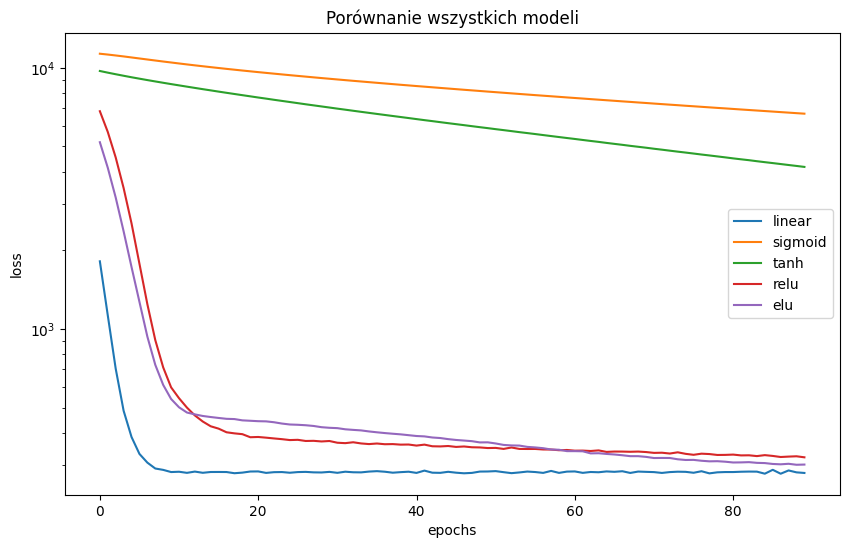

In [26]:
wykres_2 = plot_histories(histories_2)
wykres_2

In [27]:
for act, hist in histories_2.items():
    val_loss, mae = hist.model.evaluate(X_test_scaled_2, y_test_2, verbose=0)
    print(f"{act} mae: {mae}, val_loss: {val_loss}")

linear mae: 14.320189476013184, val_loss: 320.0098876953125
sigmoid mae: 63.225582122802734, val_loss: 7576.42578125
tanh mae: 47.16621017456055, val_loss: 4683.02880859375
relu mae: 13.624478340148926, val_loss: 299.2735595703125
elu mae: 13.574331283569336, val_loss: 291.8992919921875


In [28]:
# model z aktywacja linear uczyl sie najszybciej - osiagnal limit w okolo 5 epoce

# zadanie 4 

In [29]:
from sklearn.datasets import make_classification, make_moons

def generate_classification_data(kind, random_state = 42):
    if kind == "blobs":
        X, y = make_classification(
        n_samples=1000, n_features=2, n_informative=2,
        n_redundant=0, n_clusters_per_class=2, flip_y=0.05, random_state=random_state)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    elif kind == "moons":
        X, y = make_moons(
        n_samples=1000, noise=0.2, random_state=random_state)

    else:
        raise ValueError("incorrect category")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [30]:
data_2 = generate_classification_data("blobs")
X_train_scaled_3, X_test_scaled_3, y_train_3, y_test_3 = data_2

In [31]:
data_3 = generate_classification_data("moons")
X_train_scaled_4, X_test_scaled_4, y_train_4, y_test_4 = data_3

In [32]:
def plot_decision_boundary(model, X, y, title: str = "Granica decyzyjna"):
    # 1. Wyznaczenie zakresu osi z marginesem
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 2. Tworzenie gęstej siatki punktów (200x200)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 3. Predykcja dla całej siatki
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    
    # Przekształcenie prawdopodobieństw na klasy 0/1 i format siatki
    preds = (preds > 0.5).astype(int).reshape(xx.shape)

    # 4. Rysowanie tła i rzeczywistych punktów
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=30)
    
    plt.title(title)
    plt.xlabel("Cecha 1 (X1)")
    plt.ylabel("Cecha 2 (X2)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [33]:
# --- MOONS ---
m_moons_brak = build_model(2, [], 'relu', 'classification')
m_moons_maly = build_model(2, [8], 'relu', 'classification')
m_moons_gleb = build_model(2, [32, 32], 'relu', 'classification')

hist_moons_no = train_model(m_moons_brak, X_train_scaled_4, y_train_4, 100, 'classification')
hist_moons_one = train_model(m_moons_maly, X_train_scaled_4, y_train_4, 100, 'classification')
hist_moons_two = train_model(m_moons_gleb, X_train_scaled_4, y_train_4, 100, 'classification')

# --- BLOBS ---
m_blobs_brak = build_model(2, [], 'relu', 'classification')
m_blobs_maly = build_model(2, [8], 'relu', 'classification')
m_blobs_gleb = build_model(2, [32, 32], 'relu', 'classification')

hist_blobs_no = train_model(m_blobs_brak, X_train_scaled_3, y_train_3, 100, 'classification')
hist_blobs_one = train_model(m_blobs_maly, X_train_scaled_3, y_train_3, 100, 'classification')
hist_blobs_two = train_model(m_blobs_gleb, X_train_scaled_3, y_train_3, 100, 'classification')

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3219 - loss: 0.7668 - val_accuracy: 0.4125 - val_loss: 0.7071
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5344 - loss: 0.6499 - val_accuracy: 0.6125 - val_loss: 0.6074
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6812 - loss: 0.5627 - val_accuracy: 0.7250 - val_loss: 0.5364
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7531 - loss: 0.5012 - val_accuracy: 0.7688 - val_loss: 0.4845
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7875 - loss: 0.4569 - val_accuracy: 0.8000 - val_loss: 0.4471
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8031 - loss: 0.4247 - val_accuracy: 0.8062 - val_loss: 0.4191
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8156 - loss: 0.4009 - val_accuracy: 0.8062 - val_loss: 0.3970
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8219 - loss: 0.3818 - val_accuracy: 0.8188 - v

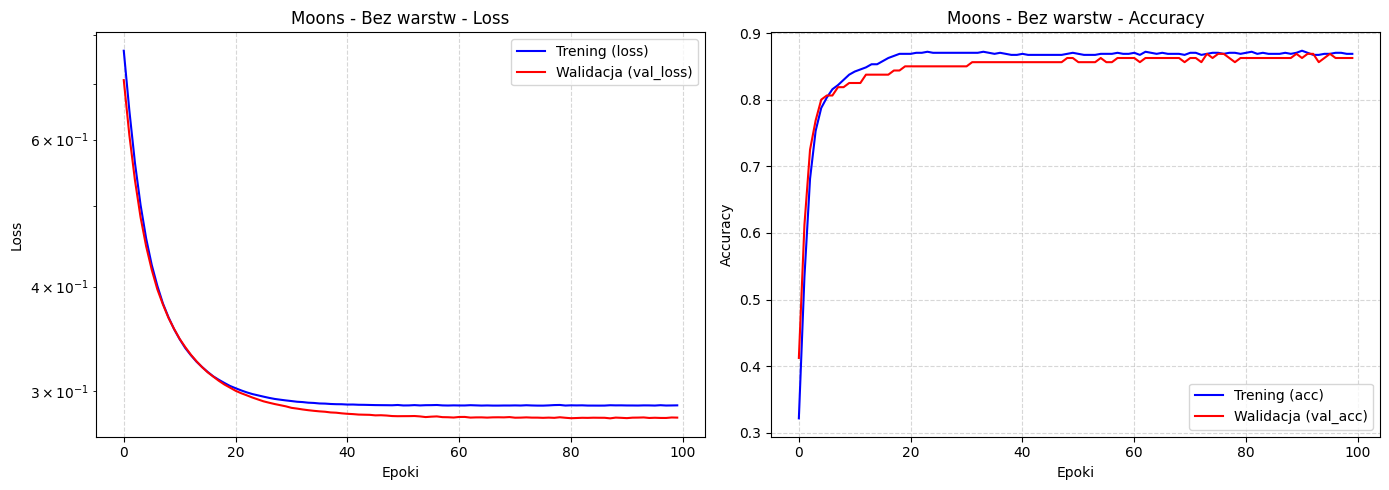

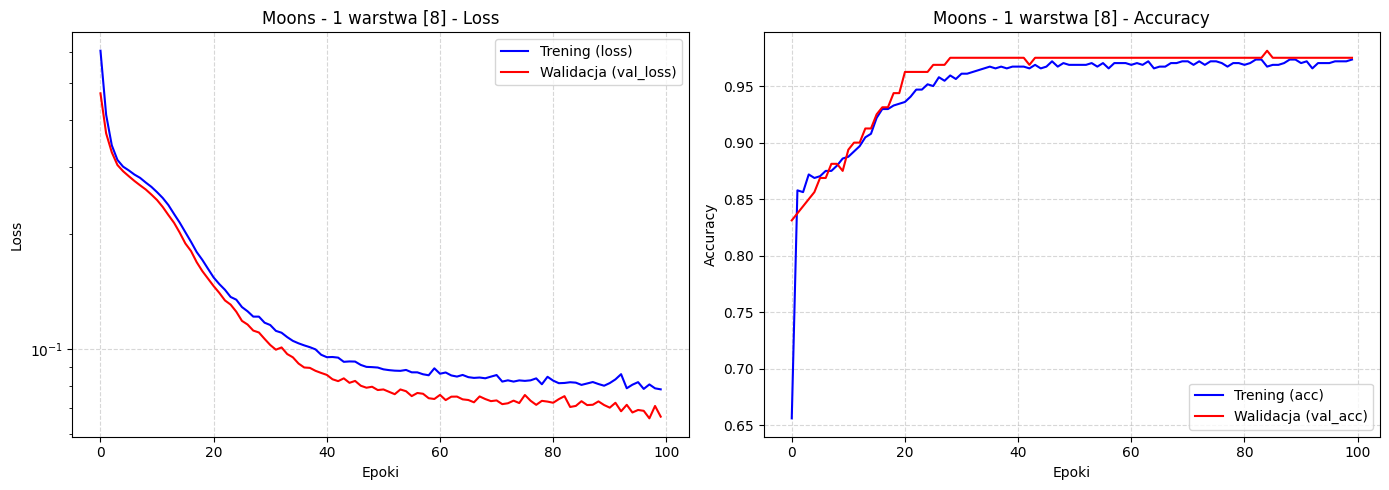

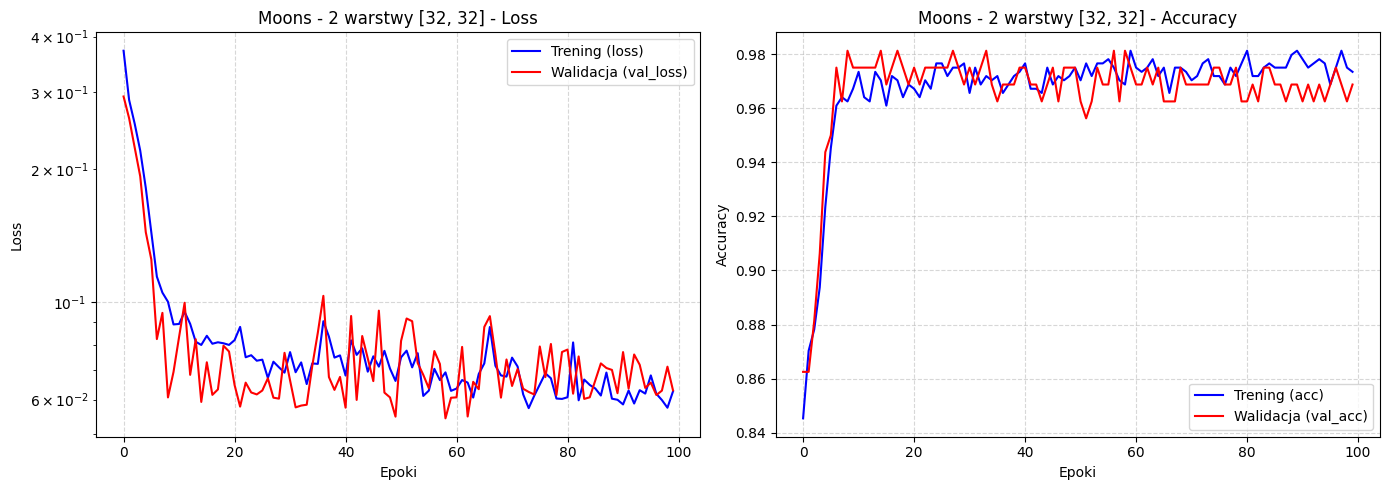

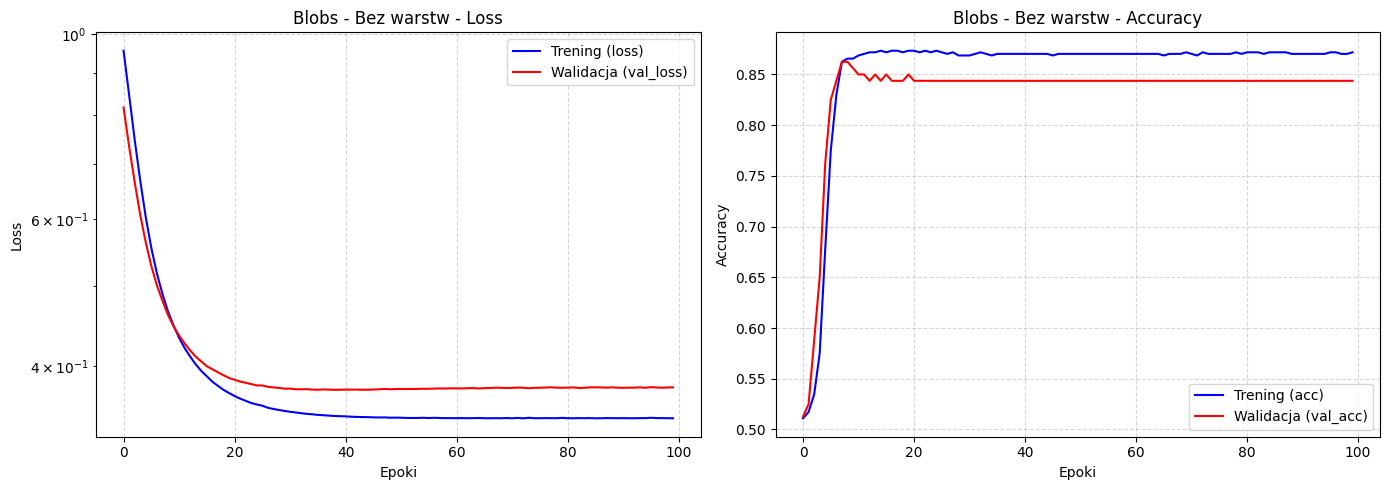

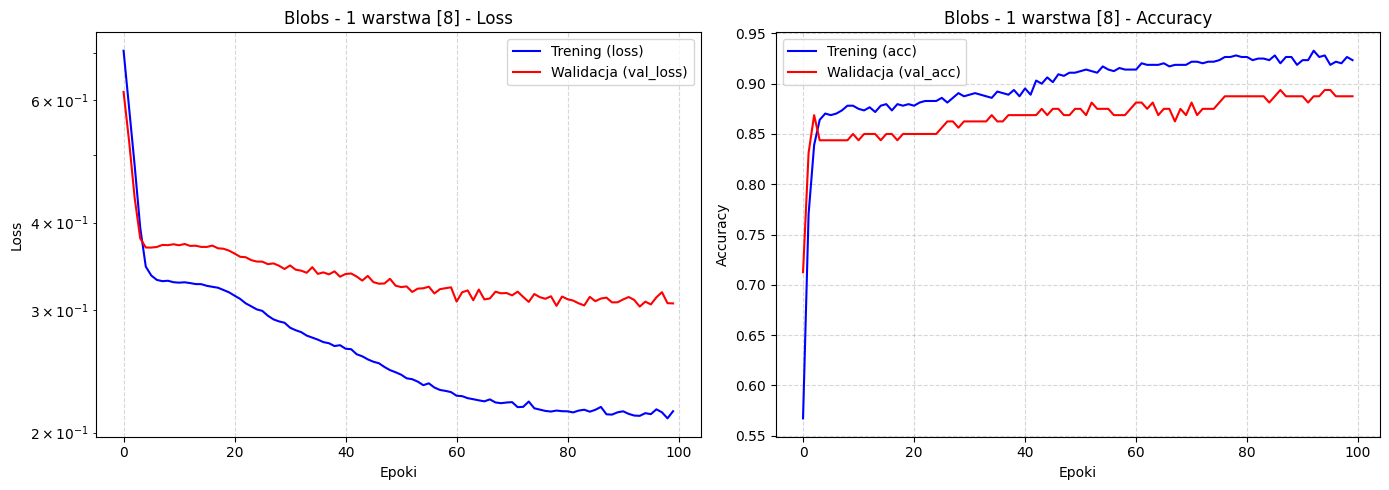

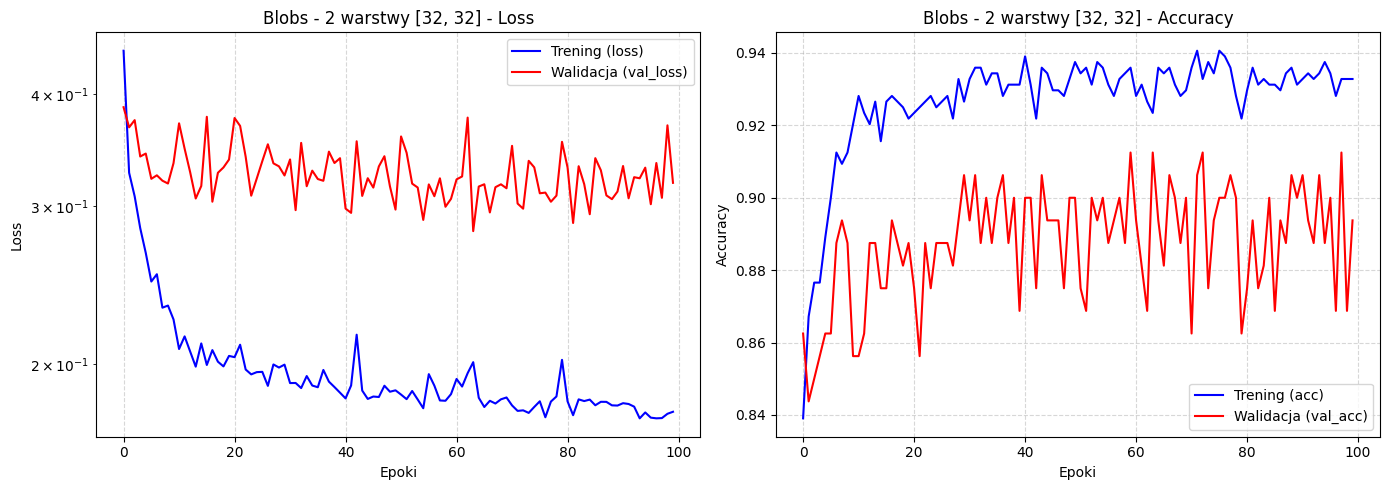

In [34]:
histories = {
    "Moons - Bez warstw": hist_moons_no,
    "Moons - 1 warstwa [8]": hist_moons_one,
    "Moons - 2 warstwy [32, 32]": hist_moons_two,
    "Blobs - Bez warstw": hist_blobs_no,
    "Blobs - 1 warstwa [8]": hist_blobs_one,
    "Blobs - 2 warstwy [32, 32]": hist_blobs_two,
}

for title, hist in histories.items():
    plot_history(hist, title=title)

In [35]:
# model moons bez warstwy nie radzi sobie poniewaz rysuje prosta linie a dane maja ksztalty pierscieni
# modele nie osiagna 100 % skutecznosci poniewaz jest dodane 5 procent szumu

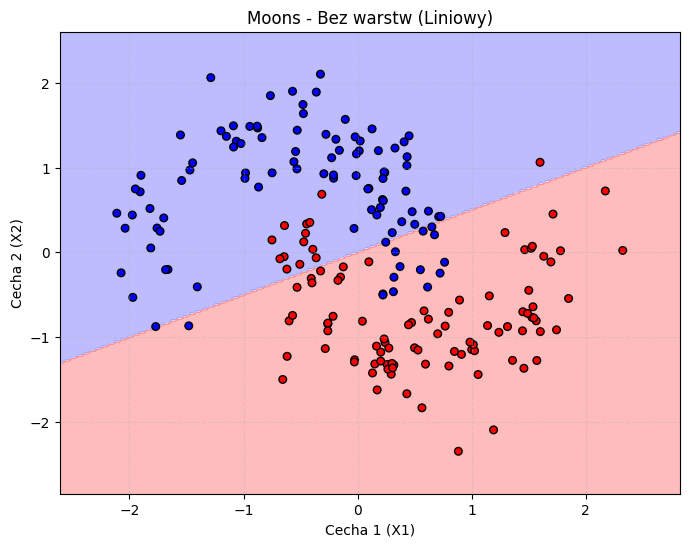

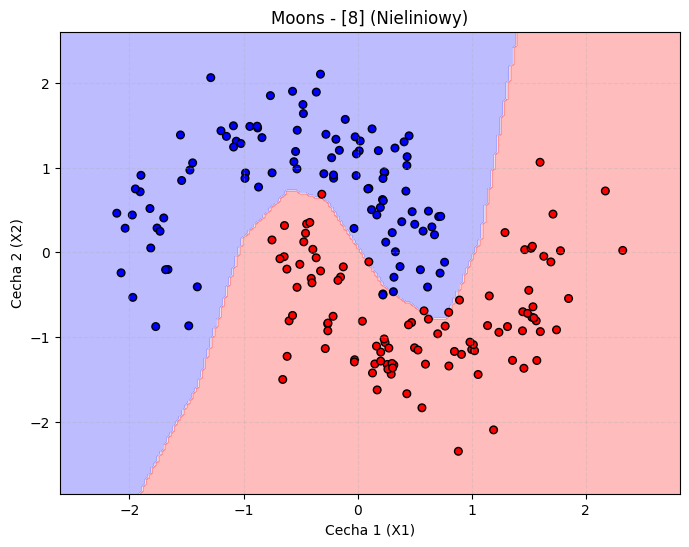

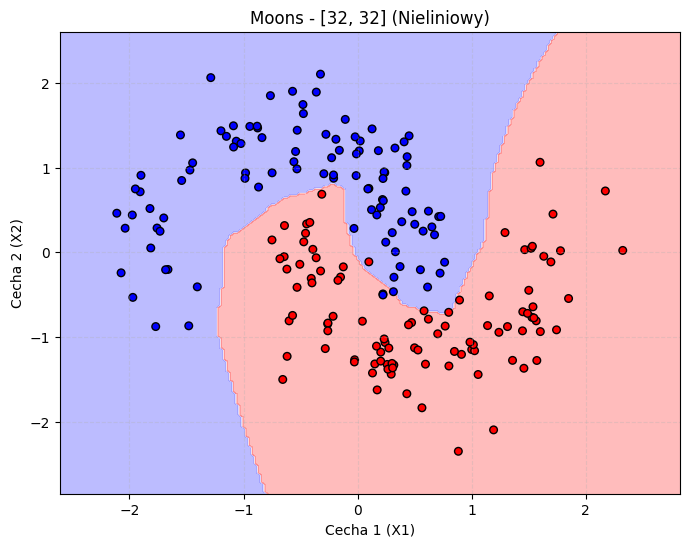

In [36]:
# Zobaczysz prostą kreskę przecinającą dane:
plot_decision_boundary(m_moons_brak, X_test_scaled_4, y_test_4, title="Moons - Bez warstw (Liniowy)")

plot_decision_boundary(m_moons_maly, X_test_scaled_4, y_test_4, title="Moons - [8] (Nieliniowy)")
# Zobaczysz granicę w kształcie litery S, która idealnie omija księżyce:
plot_decision_boundary(m_moons_gleb, X_test_scaled_4, y_test_4, title="Moons - [32, 32] (Nieliniowy)")

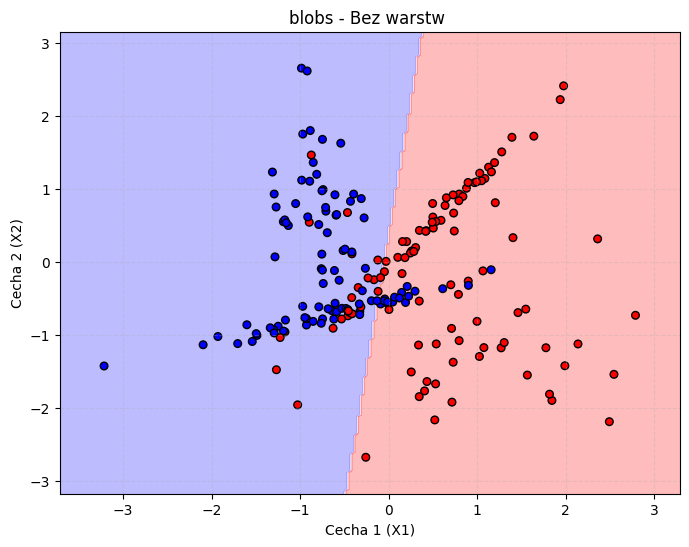

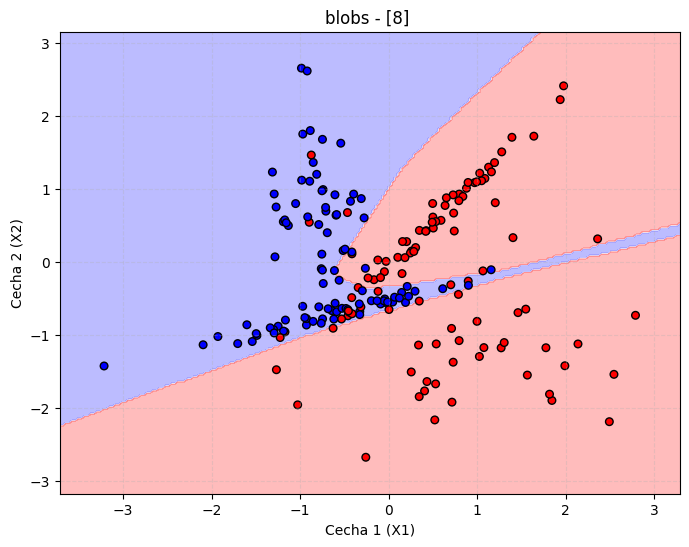

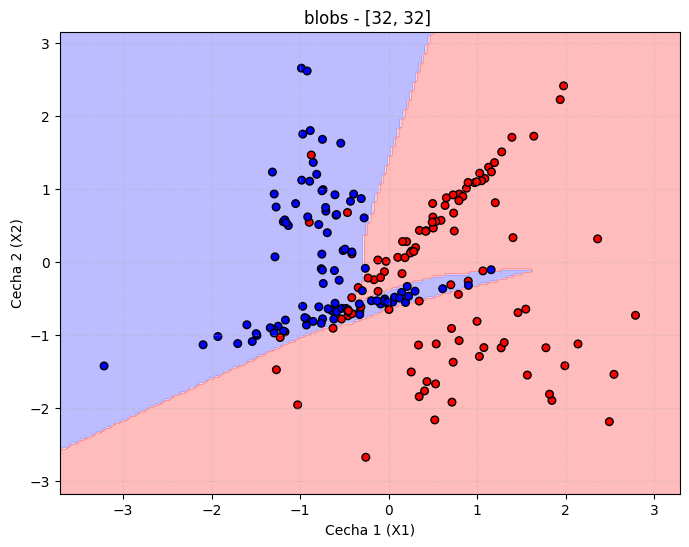

In [37]:
plot_decision_boundary(m_blobs_brak, X_test_scaled_3, y_test_3, title="blobs - Bez warstw ")

plot_decision_boundary(m_blobs_maly, X_test_scaled_3, y_test_3, title="blobs - [8] ")
plot_decision_boundary(m_blobs_gleb, X_test_scaled_3, y_test_3, title="blobs - [32, 32] ")

# zadanie 5

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

In [39]:
X_5, y_5 = make_classification(n_samples=3000, n_features=10, n_informative=5, n_classes=4, class_sep=1.0)

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled_5 = scaler.fit_transform(X_train_5)
X_test_scaled_5 = scaler.transform(X_test_5)

In [40]:
model_5 = Sequential([
    layers.Input(shape = (10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')])


model_5.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',        # metryka do obserwacji
    patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
    restore_best_weights=True  # cofa wagi do najlepszej epoki 
)

history_5 = model_5.fit(
        X_train_scaled_5, 
        y_train_5, 
        validation_split=0.2, 
        verbose=0, 
        callbacks=[early_stop],
        epochs=300
    )
history_5

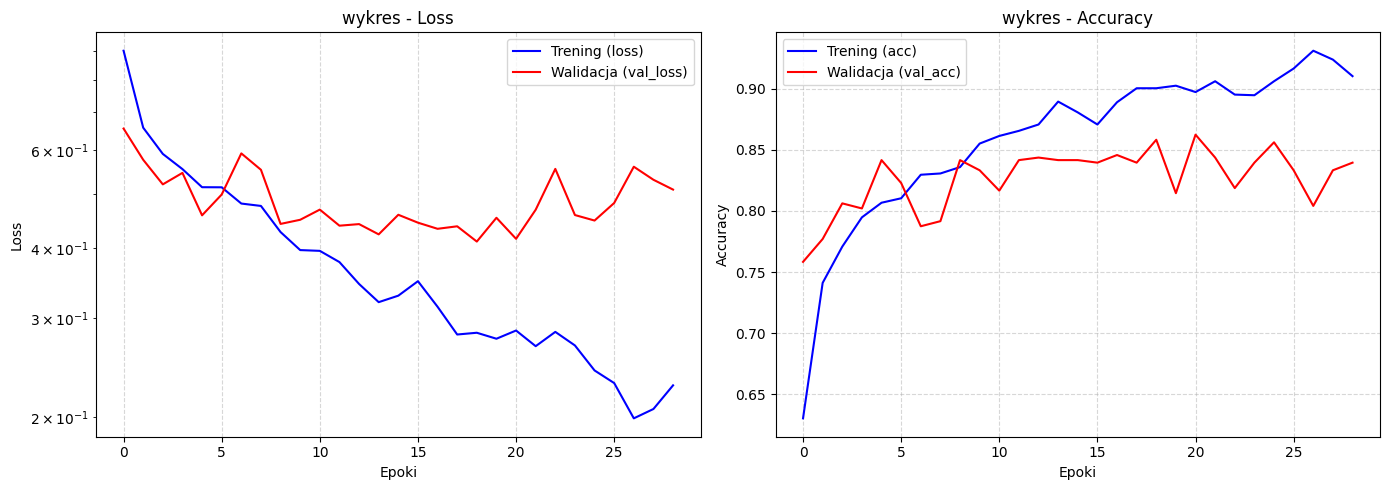

In [41]:
plot_history(history_5, cat_type = "classification", title = "wykres")

In [42]:
len(history_5.history['loss'])

29

In [43]:
model_6 = Sequential([
    layers.Input(shape = (10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')])


model_6.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

history_6 = model_6.fit(
        X_train_scaled_5, 
        y_train_5, 
        validation_split=0.2, 
        verbose=0, 
        epochs=300
    )
history_6

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

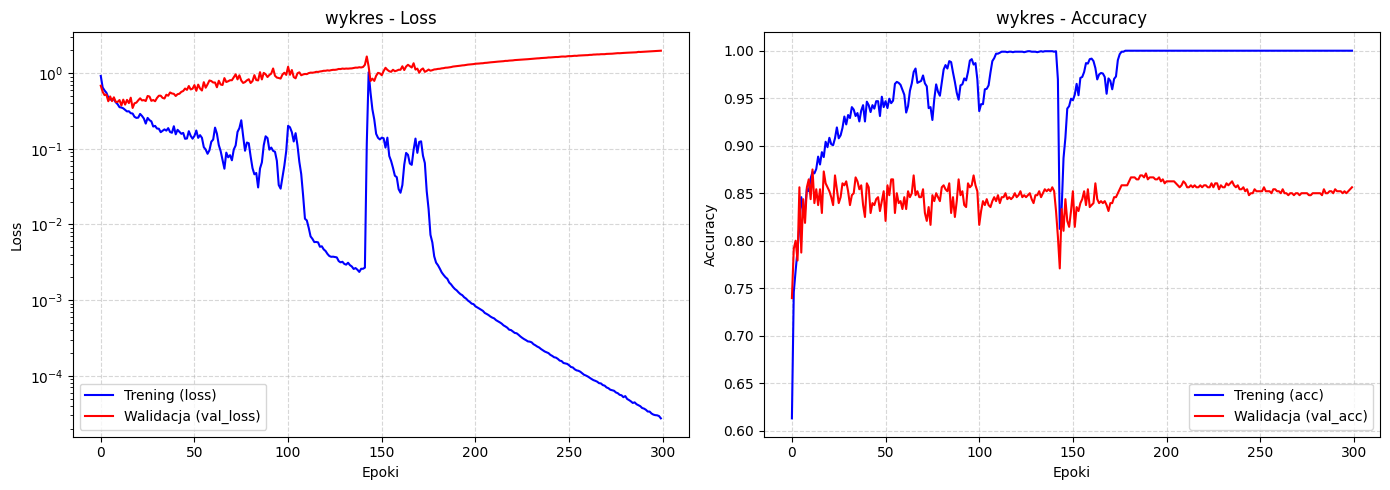

In [45]:
plot_history(history_6, cat_type = "classification", title = "wykres")

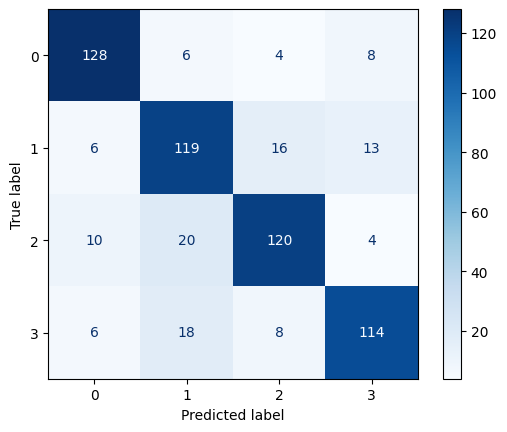

0.8016666666666666

In [46]:
def evaluate_classifier(model, X_test, y_test):
    
    y_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.show()

    return acc
model_5_acc = evaluate_classifier(model_5, X_test_scaled_5, y_test_5)
model_5_acc

Early Stopping: Przerywa trening automatycznie w momencie, gdy model przestaje robić postępy na danych walidacyjnych (val_loss), zapobiegając przeuczeniu (overfitting) i marnowaniu czasu.

Parametr patience (bufor cierpliwości): To nie „długość przeuczenia”, lecz liczba kolejnych epok bez poprawy rekordu, jakie dajesz modelowi, zanim trening zostanie przerwany.

In [47]:
# model najczesciej myli klase 1 z klasa 2 

# zadanie 6

In [49]:
def run_experiment(X_train, y_train, depths, widths, activations):
    
    histories = {}


    for dep in depths:
            for wid in widths:
                for act in activations:
                    model = Sequential([
                    layers.Input(shape=(10,))
                    ])
                    for _ in range(dep):
                        model.add(layers.Dense(wid, activation = act))
                    model.add(layers.Dense(4, activation='softmax'))

                    model.compile(
                    optimizer = keras.optimizers.Adam(learning_rate=0.01),
                    loss = 'sparse_categorical_crossentropy',
                    metrics = ['accuracy'])
                
                    early_stop = EarlyStopping(
                    monitor='val_loss',        # metryka do obserwacji
                    patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
                    restore_best_weights=True  # cofa wagi do najlepszej epoki 
                )

                    history = model.fit(
                    X_train, 
                    y_train, 
                    validation_split=0.2, 
                    verbose=0, 
                    epochs=300,
                    callbacks = [early_stop]
                )

                    histories[f"d{dep}_w{wid}_{act}"] = history

    return histories 

hist = run_experiment(X_train_scaled_5, y_train_5, [1, 2], [16, 64], ['relu', 'tanh'])

In [50]:
hist

{'d1_w16_relu': <keras.src.callbacks.history.History at 0x1796adb30>,
 'd1_w16_tanh': <keras.src.callbacks.history.History at 0x167d9a710>,
 'd1_w64_relu': <keras.src.callbacks.history.History at 0x166f44950>,
 'd1_w64_tanh': <keras.src.callbacks.history.History at 0x16de0f6d0>,
 'd2_w16_relu': <keras.src.callbacks.history.History at 0x16de64ed0>,
 'd2_w16_tanh': <keras.src.callbacks.history.History at 0x16d579630>,
 'd2_w64_relu': <keras.src.callbacks.history.History at 0x17993add0>,
 'd2_w64_tanh': <keras.src.callbacks.history.History at 0x17da454e0>}

In [58]:
def to_df_v2(models):
    data = []
    for name, history in models.items():
        mini_data = {"name" :name,
                     "loss": history.history['loss'][-1],
                     "val_loss": history.history['val_loss'][-1],
                     "val_acc": history.history['val_accuracy'][-1]
                    }
        data.append(mini_data)
    
    df = pd.DataFrame(data)
    return df

In [59]:
df2 = to_df_v2(hist)
df2

,name,loss,val_loss,val_acc
0,d1_w16_relu,0.454732,0.469078,0.825000
1,d1_w16_tanh,0.400230,0.443013,0.850000
2,d1_w64_relu,0.291841,0.396927,0.850000
3,d1_w64_tanh,0.287365,0.442747,0.822917
4,d2_w16_relu,0.312963,0.453598,0.850000
5,d2_w16_tanh,0.281673,0.405397,0.852083
6,d2_w64_relu,0.223788,0.467287,0.845833
7,d2_w64_tanh,0.115343,0.420064,0.864583


In [55]:
hist['d1_w16_relu'].history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [65]:
test_results = []

for name, h in hist.items():
    loss, acc = h.model.evaluate(X_test_scaled_5, y_test_5, verbose=0)
    test_results.append({
        "Konfiguracja": name,
        "Liczba parametrów": h.model.count_params(),     
        "Liczba epok": len(h.history['loss']),
        "Dokładność testowa": round(acc, 4)
    })

df_3 = pd.DataFrame(test_results)
df_3 = df_3.sort_values(by= 'Dokładność testowa', ascending = False).reset_index(drop=True)

df_3

,Konfiguracja,Liczba parametrów,Liczba epok,Dokładność testowa
0,d2_w64_tanh,5124,32,0.8200
1,d1_w64_relu,964,43,0.8117
2,d2_w16_tanh,516,52,0.8117
3,d2_w64_relu,5124,20,0.8083
4,d1_w16_relu,244,87,0.8000
5,d1_w64_tanh,964,34,0.7967
6,d2_w16_relu,516,43,0.7950
7,d1_w16_tanh,244,42,0.7900


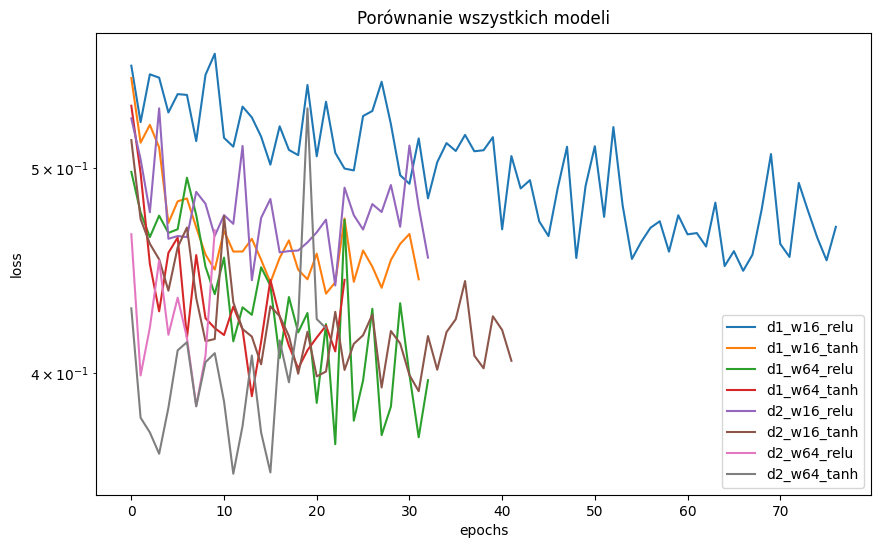

In [66]:
plots = plot_histories(hist)

In [70]:
top_keys = ['d2_w64_tanh', 'd1_w64_relu', 'd2_w16_tanh']

top_3_hist = {k: hist[k] for k in top_keys}
top_3_hist

{'d2_w64_tanh': <keras.src.callbacks.history.History at 0x17da454e0>,
 'd1_w64_relu': <keras.src.callbacks.history.History at 0x166f44950>,
 'd2_w16_tanh': <keras.src.callbacks.history.History at 0x16d579630>}

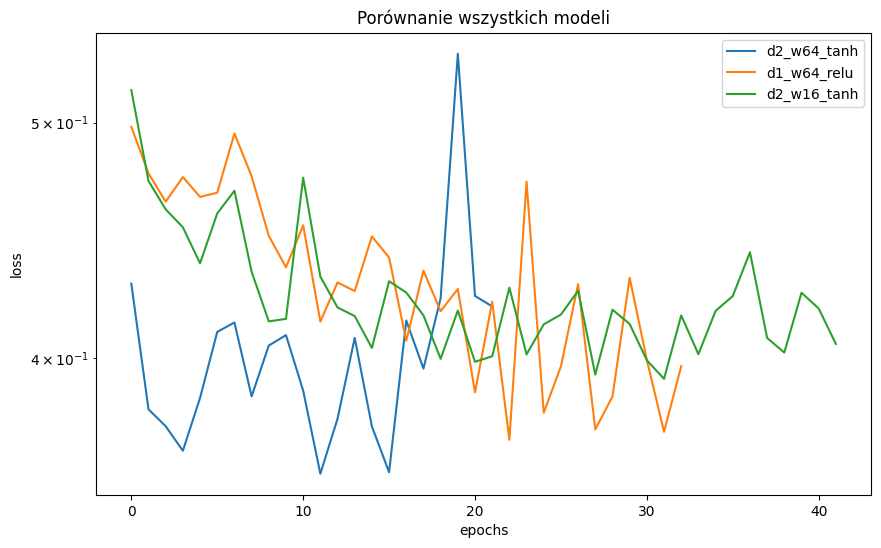

In [71]:
plots = plot_histories(top_3_hist)

In [72]:
best_model = hist['d2_w64_tanh'].model
best_model

<Sequential name=sequential_26, built=True>

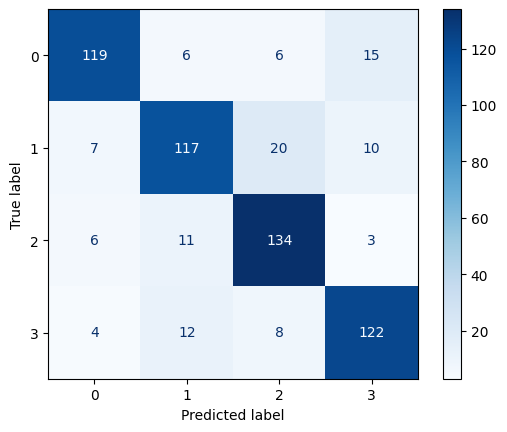

0.82

In [74]:
b_model = evaluate_classifier(best_model, X_test_scaled_5, y_test_5)
b_model

In [75]:
df_3

,Konfiguracja,Liczba parametrów,Liczba epok,Dokładność testowa
0,d2_w64_tanh,5124,32,0.8200
1,d1_w64_relu,964,43,0.8117
2,d2_w16_tanh,516,52,0.8117
3,d2_w64_relu,5124,20,0.8083
4,d1_w16_relu,244,87,0.8000
5,d1_w64_tanh,964,34,0.7967
6,d2_w16_relu,516,43,0.7950
7,d1_w16_tanh,244,42,0.7900


In [ ]:
# najlepszy model byl najwiekszy , liczba neuronow - 64 zdominowala gorny ranking, lecz model najslabszy osiagnal 79 acc
# a najlepszy 82 wiec wieksze 